In [1]:
# ====== Import the required modules
import pandas as pd
import yfinance as yf
from prophet import Prophet
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import logging


In [2]:
# ====== Other settings for logging and pandas
logging.getLogger('prophet').setLevel(logging.WARNING)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
# ====== Define the ticker and date range
ticker = "NAIL"
end_date = datetime.now() # Current date and time
start_date = end_date - timedelta(days=5*365) # Approx 5 years back (ignores leap years)
end_date = end_date.strftime('%Y-%m-%d') 
start_date = start_date.strftime('%Y-%m-%d') 

print(end_date)
print(start_date)
# Fetch data using yfinance
stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
display(stock_data.sample(5))

2025-03-18
2020-03-19
YF.download() has changed argument auto_adjust default to True


Price,Close,High,Low,Open,Volume
Ticker,NAIL,NAIL,NAIL,NAIL,NAIL
Date,,,,,
2022-11-25,30.071941,30.235483,29.463366,29.625916,126200
2024-08-23,156.822922,157.371710,141.846074,143.472464,750600
2024-03-26,139.692184,143.906095,139.293241,142.215539,82100
2025-03-07,72.349998,73.690002,68.846001,72.529999,309500
2022-09-29,22.152533,23.153609,21.716420,23.153609,422400


In [4]:
# Extract the 'Price' level from the MultiIndex and use it as column names
if isinstance(stock_data.columns, pd.MultiIndex):
    # Get the 'Price' level values (first element of each tuple)
    new_columns = [col[0] for col in stock_data.columns]
    stock_data.columns = new_columns  # Flatten to single-level columns

# Verify the updated column names
print("\nUpdated column structure:")
print(stock_data.columns)
display(stock_data.sample(5))


Updated column structure:
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Close,High,Low,Open,Volume
Date,,,,,
2025-02-21,69.599998,77.440002,68.199997,77.190002,1068300
2022-11-30,31.211779,31.211779,27.504823,28.823072,613400
2022-07-11,30.795492,31.765843,30.220617,30.319733,390500
2021-01-07,47.962463,48.339107,44.516182,44.810559,967300
2022-04-21,38.913132,42.907529,38.298611,42.183979,810900


In [5]:
# ====== Prepare data for Prophet using 'Close'
df = stock_data[['Close']].reset_index()
df.columns = ['ds', 'y']  # Rename to Prophet-compatible columns

# Handle missing values and ensure datetime format
df = df.dropna()
df['ds'] = pd.to_datetime(df['ds'])

# Display the cleaned DataFrame sample
print("\nCleaned DataFrame (first 5 rows):")
display(df.head())


Cleaned DataFrame (first 5 rows):


,ds,y
0,2020-03-19,8.210687
1,2020-03-20,7.547097
2,2020-03-23,6.704238
3,2020-03-24,9.624211
4,2020-03-25,12.260709


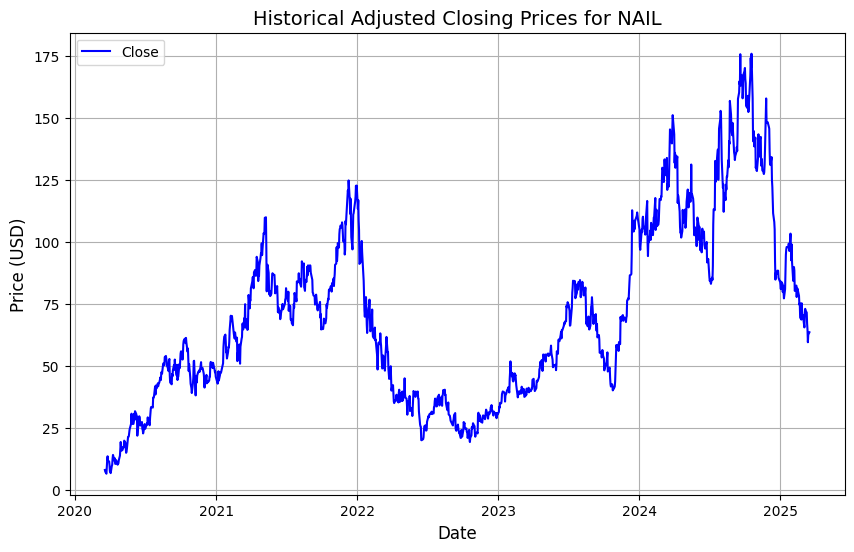


Basic Statistics of Adjusted Close Prices:
count    1255.000000
mean       69.733796
std        36.391707
min         6.704238
25%        40.355278
50%        64.760857
75%        92.416035
max       175.817688
Name: y, dtype: float64


In [6]:
# Plot historical data
plt.figure(figsize=(10, 6))
plt.plot(df['ds'], df['y'], label='Close', color='blue')
plt.title(f'Historical Adjusted Closing Prices for {ticker}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Basic statistics
print("\nBasic Statistics of Adjusted Close Prices:")
print(df['y'].describe())

In [7]:
# ======= Make forecast dataframe
horizon = 14
latest_dates = datetime.now()  - timedelta(days=horizon*5)
current_df = df[df['ds'] >= latest_dates]
display(current_df.head(3))
display(current_df.tail(3))

,ds,y
1209,2025-01-08,82.449997
1210,2025-01-10,77.309998
1211,2025-01-13,81.019997


,ds,y
1252,2025-03-13,59.650002
1253,2025-03-14,62.639999
1254,2025-03-17,63.669998


In [8]:
# ====== Initialize and fit the Prophet model
model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.05  # Adjusts trend flexibility
)
model.fit(current_df)

20:28:02 - cmdstanpy - INFO - Chain [1] start processing
20:28:02 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# ====== Create future dataframe for the next 30 days
future = model.make_future_dataframe(periods=horizon)
display(future.tail(horizon))

,ds
46,2025-03-18
47,2025-03-19
48,2025-03-20
49,2025-03-21
50,2025-03-22
51,2025-03-23
52,2025-03-24
53,2025-03-25
54,2025-03-26
55,2025-03-27


In [10]:
# Generate forecast
forecast = model.predict(future)
display(forecast.tail(horizon))

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2025-03-18,51.535345,61.874695,69.349253,51.535345,51.535345,14.116440,14.116440,14.116440,366.037143,366.037143,366.037143,18.439123,18.439123,18.439123,-370.359826,-370.359826,-370.359826,0.0,0.0,0.0,65.651785
47,2025-03-19,51.950936,66.302991,73.347511,51.950936,51.950936,17.718250,17.718250,17.718250,366.037143,366.037143,366.037143,18.690067,18.690067,18.690067,-367.008959,-367.008959,-367.008959,0.0,0.0,0.0,69.669186
48,2025-03-20,52.366526,72.513954,79.562357,52.366526,52.366526,23.830968,23.830968,23.830968,366.037143,366.037143,366.037143,19.422600,19.422600,19.422600,-361.628775,-361.628775,-361.628775,0.0,0.0,0.0,76.197494
49,2025-03-21,52.782117,78.904753,86.028439,52.782117,52.782117,29.714800,29.714800,29.714800,366.037143,366.037143,366.037143,17.448372,17.448372,17.448372,-353.770714,-353.770714,-353.770714,0.0,0.0,0.0,82.496917
50,2025-03-22,53.197708,26.953277,34.117528,53.197708,53.197708,-22.678218,-22.678218,-22.678218,366.037143,366.037143,366.037143,-45.754638,-45.754638,-45.754638,-342.960723,-342.960723,-342.960723,0.0,0.0,0.0,30.519490
51,2025-03-23,53.613298,41.654193,48.781099,53.613298,53.613298,-8.426191,-8.426191,-8.426191,366.037143,366.037143,366.037143,-45.754665,-45.754665,-45.754665,-328.708669,-328.708669,-328.708669,0.0,0.0,0.0,45.187107
52,2025-03-24,54.028889,123.401801,130.459795,54.028889,54.028889,73.026926,73.026926,73.026926,366.037143,366.037143,366.037143,17.509142,17.509142,17.509142,-310.519359,-310.519359,-310.519359,0.0,0.0,0.0,127.055815
53,2025-03-25,54.444480,147.231970,154.613511,54.444479,54.444480,96.571287,96.571287,96.571287,366.037143,366.037143,366.037143,18.439123,18.439123,18.439123,-287.904979,-287.904979,-287.904979,0.0,0.0,0.0,151.015766
54,2025-03-26,54.860070,175.626997,182.629485,54.860070,54.860070,124.328474,124.328474,124.328474,366.037143,366.037143,366.037143,18.690067,18.690067,18.690067,-260.398735,-260.398735,-260.398735,0.0,0.0,0.0,179.188544
55,2025-03-27,55.275661,209.381283,216.939404,55.275660,55.275661,157.890333,157.890333,157.890333,366.037143,366.037143,366.037143,19.422600,19.422600,19.422600,-227.569410,-227.569410,-227.569410,0.0,0.0,0.0,213.165993


In [11]:
# ====== Display the last 5 rows of the forecast
display(forecast[['ds', 'trend', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon))

,ds,trend,yhat,yhat_lower,yhat_upper
46,2025-03-18,51.535345,65.651785,61.874695,69.349253
47,2025-03-19,51.950936,69.669186,66.302991,73.347511
48,2025-03-20,52.366526,76.197494,72.513954,79.562357
49,2025-03-21,52.782117,82.496917,78.904753,86.028439
50,2025-03-22,53.197708,30.519490,26.953277,34.117528
51,2025-03-23,53.613298,45.187107,41.654193,48.781099
52,2025-03-24,54.028889,127.055815,123.401801,130.459795
53,2025-03-25,54.444480,151.015766,147.231970,154.613511
54,2025-03-26,54.860070,179.188544,175.626997,182.629485
55,2025-03-27,55.275661,213.165993,209.381283,216.939404


In [12]:
# ====== Optimized Prophet Model
model = Prophet(
    # daily_seasonality=False,  # Disable daily seasonality
    # weekly_seasonality=True,
    # yearly_seasonality=True,
    changepoint_prior_scale=0.1,  # Increase trend flexibility
    seasonality_prior_scale=1.0   # Reduce seasonality strength
)

# Add logistic growth with bounds (assuming realistic range based on data)
# df['cap'] = 150  # Upper bound based on historical max
# df['floor'] = 5   # Lower bound based on historical min
# model.growth = 'logistic' # Requires the cap & floor when used

# Fit the model
model.fit(df)

20:28:02 - cmdstanpy - INFO - Chain [1] start processing
20:28:02 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
# ====== Create future dataframe for 14 days
future = model.make_future_dataframe(periods=horizon)
# future['cap'] = 150  # Extend bounds to future
# future['floor'] = 5
display(future.tail(horizon))

,ds
1255,2025-03-18
1256,2025-03-19
1257,2025-03-20
1258,2025-03-21
1259,2025-03-22
1260,2025-03-23
1261,2025-03-24
1262,2025-03-25
1263,2025-03-26
1264,2025-03-27


In [14]:
# ====== Generate forecast
forecast = model.predict(future)
display(forecast.tail(horizon))

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1255,2025-03-18,104.582855,80.311317,116.937820,104.582855,104.582855,-5.837892,-5.837892,-5.837892,0.252751,0.252751,0.252751,-6.090643,-6.090643,-6.090643,0.0,0.0,0.0,98.744963
1256,2025-03-19,104.517769,82.194380,117.724430,104.517769,104.517769,-4.945577,-4.945577,-4.945577,0.471743,0.471743,0.471743,-5.417320,-5.417320,-5.417320,0.0,0.0,0.0,99.572191
1257,2025-03-20,104.452682,82.750468,117.617931,104.452682,104.452682,-4.241604,-4.241604,-4.241604,0.534732,0.534732,0.534732,-4.776335,-4.776335,-4.776335,0.0,0.0,0.0,100.211078
1258,2025-03-21,104.387595,83.342505,117.764758,104.387595,104.387595,-3.653645,-3.653645,-3.653645,0.523279,0.523279,0.523279,-4.176925,-4.176925,-4.176925,0.0,0.0,0.0,100.733950
1259,2025-03-22,104.322508,81.385173,116.990430,104.322508,104.322508,-4.703393,-4.703393,-4.703393,-1.075859,-1.075859,-1.075859,-3.627535,-3.627535,-3.627535,0.0,0.0,0.0,99.619115
1260,2025-03-23,104.257422,82.928227,117.386106,104.257422,104.257422,-4.211500,-4.211500,-4.211500,-1.075858,-1.075858,-1.075858,-3.135642,-3.135642,-3.135642,0.0,0.0,0.0,100.045922
1261,2025-03-24,104.192335,84.522537,119.666747,104.192335,104.192335,-2.338381,-2.338381,-2.338381,0.369212,0.369212,0.369212,-2.707594,-2.707594,-2.707594,0.0,0.0,0.0,101.853953
1262,2025-03-25,104.127248,84.803367,118.580080,104.127248,104.127248,-2.095722,-2.095722,-2.095722,0.252751,0.252751,0.252751,-2.348473,-2.348473,-2.348473,0.0,0.0,0.0,102.031526
1263,2025-03-26,104.062161,84.087639,120.008231,104.062161,104.062161,-1.590242,-1.590242,-1.590242,0.471743,0.471743,0.471743,-2.061986,-2.061986,-2.061986,0.0,0.0,0.0,102.471919
1264,2025-03-27,103.997074,85.555681,120.604201,103.997074,103.997074,-1.315647,-1.315647,-1.315647,0.534732,0.534732,0.534732,-1.850378,-1.850378,-1.850378,0.0,0.0,0.0,102.681428


In [15]:
# Display the last 14 days of the forecast
print("\nForecast for the next 14 days:")
display(forecast[['ds', 'trend', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon))


Forecast for the next 14 days:


,ds,trend,yhat,yhat_lower,yhat_upper
1255,2025-03-18,104.582855,98.744963,80.311317,116.937820
1256,2025-03-19,104.517769,99.572191,82.194380,117.724430
1257,2025-03-20,104.452682,100.211078,82.750468,117.617931
1258,2025-03-21,104.387595,100.733950,83.342505,117.764758
1259,2025-03-22,104.322508,99.619115,81.385173,116.990430
1260,2025-03-23,104.257422,100.045922,82.928227,117.386106
1261,2025-03-24,104.192335,101.853953,84.522537,119.666747
1262,2025-03-25,104.127248,102.031526,84.803367,118.580080
1263,2025-03-26,104.062161,102.471919,84.087639,120.008231
1264,2025-03-27,103.997074,102.681428,85.555681,120.604201


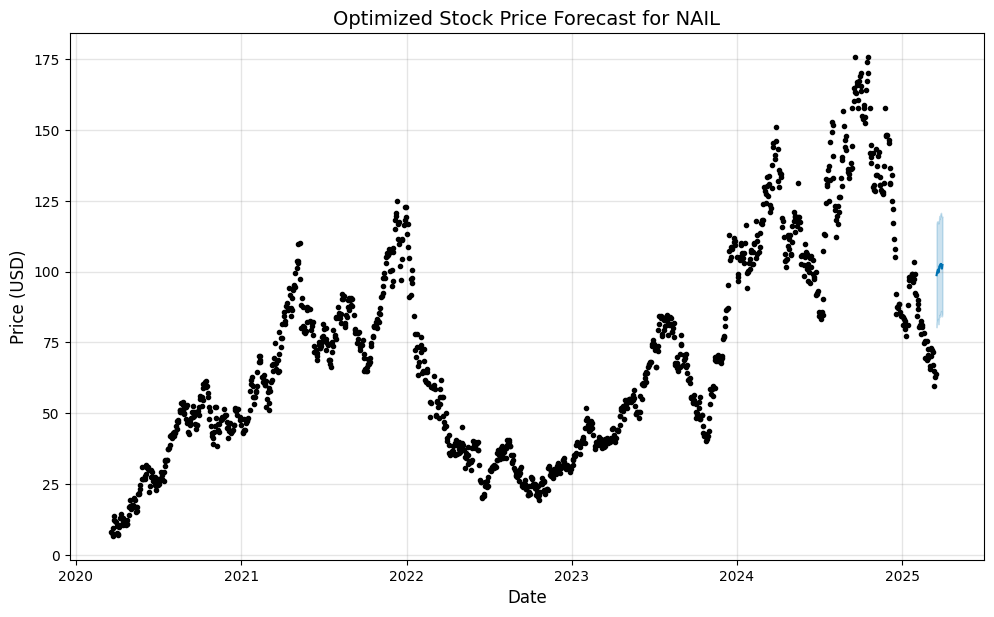

In [16]:
# ====== Plot forecast
fig1 = model.plot(forecast[['ds', 'trend', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon))
plt.title(f'Optimized Stock Price Forecast for {ticker}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True)
plt.show()

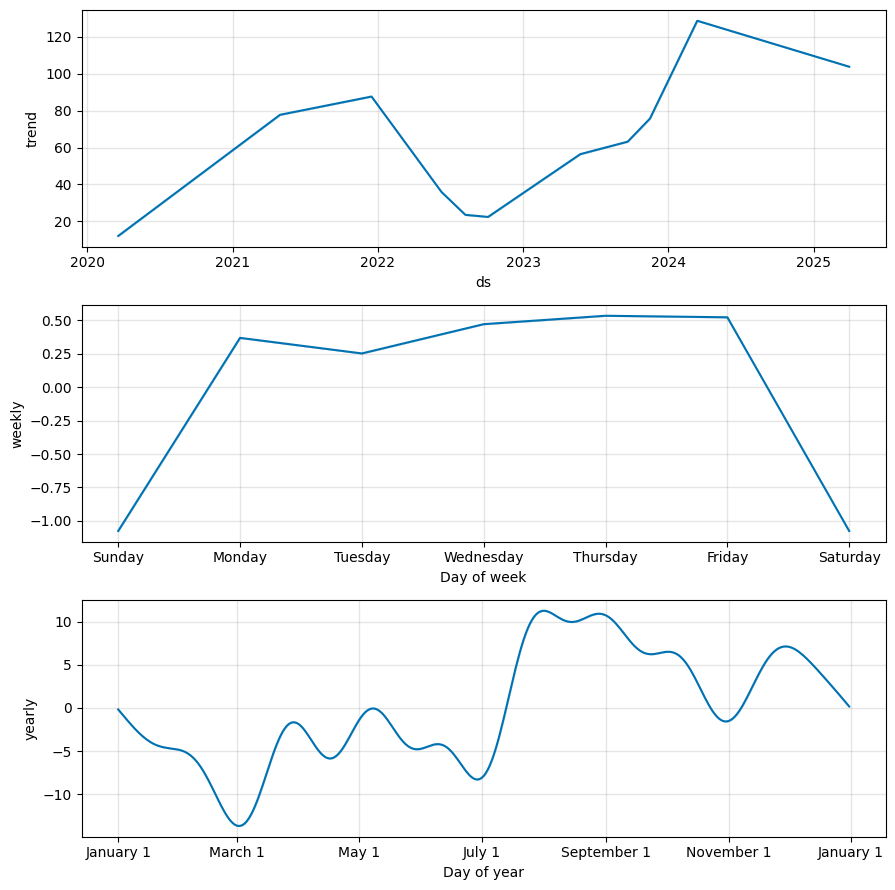

In [17]:
# ====== Plot components
fig2 = model.plot_components(forecast)
plt.show()